In [1]:
# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd
import re

In [2]:
def removeLow(arr, cutoff = 1e-3):
    func = lambda x: (x > cutoff) * x
    vfunc = np.vectorize(func)
    return vfunc(arr)

# Import the APCEMM results

In [3]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']

epm_bypass_data = {}

for test_id in test_ids:
    apcemm_data = lib.read_apcemm_data(
        f'/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/epm_bypass/{test_id}/outputs',
    )
    epm_bypass_data[test_id] = apcemm_data.ds_t

# Import CoCiP Results

In [4]:
# Import each CoCiP bypass dataset into a dictionary, similar to epm_bypass_data
cocip_bypass_files = {
    '110T205L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T205L25-bypass.nc",
    '110T218L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T218L25-bypass.nc",
    '110T225L25': "/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/110T225L25-bypass.nc"
}

# Open each CoCiP bypass dataset and store in a dictionary for easy access
cocip_bypass_data = {}
for test_id, filepath in cocip_bypass_files.items():
    cocip_bypass_data[test_id] = xr.open_dataset(filepath)

# Import LES Results

In [5]:
num_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_number/*.csv')
mass_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_mass/*.csv')
radius_LES_csv = glob.glob('/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_radius/**/*.csv', recursive=True)

# Comparison Plots

## Ice Crystal Number Plots

In [ ]:
fig, axes = plt.subplots(1, len(temp_groups), figsize=(18, 5), sharey=True)

for i, temp in enumerate(temp_groups):
    ax = axes[i]
    # Plot APCEMM bypass results for both humidities at this temperature
    for test_id in test_ids:
        if f'T{temp}' in test_id:
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_crystal_number = [ds["Number Ice Particles"].item() for ds in ds_list]
            linestyle = '--' if test_id.startswith('110') else '-'
            label = f" APCEMM {test_id[:3]}% RHi"
            ax.plot(times_arr, ice_crystal_number, linestyle=linestyle, color=color_map[temp], label=label)

    # Plot LES results for this temperature
    for csv_file in num_LES_csv:
        if f'T{temp}' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            label = f"LES {csv_file.split('/')[-1][:3]}% RHi"
            linestyle = '--' if csv_file.split('/')[-1].startswith('110') else '-'
            ax.plot(df.iloc[:,0], df.iloc[:,1], linestyle=linestyle, color='k', label=label, alpha=0.7)

    ax.axhline(1e10, color='red', linestyle=':', linewidth=2, label='LES End Criteria')

    ax.set_title(f"Temperature {temp} K")
    ax.set_xlabel("Time [hours]")
    if i == 0:
        ax.set_ylabel("Ice Crystal Number")
    ax.set_yscale('log')
    ax.legend(fontsize=9)

plt.suptitle("Ice Crystal Number: LES vs APCEMM Bypass by Temperature", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Ice crystal number all on one axes

In [ ]:
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Plot APCEMM bypass results for 110% RHi for each temperature
for temp in temp_groups:
    for test_id in test_ids:
        if f'T{temp}' in test_id and test_id.startswith('110'):
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_crystal_number = [ds["Number Ice Particles"].item() for ds in ds_list]
            line, = ax.plot(
                times_arr,
                ice_crystal_number,
                color=color_map[temp],
                linestyle='-',
                alpha=1.0,
            )
            # Add label at the end of the line
            ax.text(times_arr[-1], ice_crystal_number[-1], f"APCEMM {temp}K", color=color_map[temp], fontsize=9, va='top', ha='right')

# Plot LES results for 110% RHi for each temperature
for temp in temp_groups:
    for csv_file in num_LES_csv:
        if f'T{temp}' in csv_file and '110' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            line, = ax.plot(
                df.iloc[:,0],
                df.iloc[:,1],
                color=color_map[temp],
                linestyle='--',
                alpha=0.8
            )
            # Add label at the end of the line
            ax.text(df.iloc[:,0].values[-1], df.iloc[:,1].values[-1], f"LES {temp}K", color=color_map[temp], fontsize=9, va='top', ha='center')

# Plot CoCiP result for 205K, 110% RHi
for temp in temp_groups:
    cocip_key = f'110T{temp}L25'
    if cocip_key in cocip_bypass_data:
        cocip_ds = cocip_bypass_data[cocip_key]
        ax.plot(
            cocip_ds['age_hours'].values,
            cocip_ds['n_ice_per_m'].values,
            linestyle=':',
            color=color_map[temp]
        )
    # Add label at the end of the CoCiP line
    ax.text(cocip_ds['age_hours'].values[-1] + 1, cocip_ds['n_ice_per_m'].values[-1] - (0.1*cocip_ds['n_ice_per_m'].values[-1]), f"CoCiP {temp}K", color=color_map[temp], fontsize=8.5, va='top', ha='right')

ax.set_xlim(left=0)
ax.set_xlabel("Time [hours]")
ax.set_ylabel(r'Ice Crystal Number $\left[\frac{\#}{m}\right]$')
ax.set_yscale('log')
ax.set_title("Ice Crystal Number: LES vs APCEMM vs CoCiP for RHi = 110%")
plt.tight_layout()
plt.show()


## Ice Mass Plot

In [ ]:
fig, axes = plt.subplots(1, len(temp_groups), figsize=(18, 5), sharey=True)

for i, temp in enumerate(temp_groups):
    ax = axes[i]
    # Plot APCEMM bypass ice mass for both humidities at this temperature
    for test_id in test_ids:
        if f'T{temp}' in test_id and len(epm_bypass_data[test_id]) > 0:
            ds_list = epm_bypass_data[test_id]
            times_arr = np.arange(len(ds_list)) * 10 / 60  # time in hours
            ice_mass = [ds["Ice Mass"].item() for ds in ds_list]
            linestyle = '--' if test_id.startswith('110') else '-'
            label = f"Bypass {test_id[:3]}% RHi"
            ax.plot(times_arr, ice_mass, linestyle=linestyle, color=color_map[temp], label=label)

    # Plot LES ice mass results for this temperature
    for csv_file in mass_LES_csv:
        if f'T{temp}' in csv_file:
            df = pd.read_csv(csv_file, header=None)
            label = f"LES {csv_file.split('/')[-1][:3]}% RHi"
            linestyle = '--' if csv_file.split('/')[-1].startswith('110') else '-'
            ax.plot(df.iloc[:,0], df.iloc[:,1], linestyle=linestyle, color='k', label=label, alpha=0.7)

    ax.axhline(1e-2, color='red', linestyle=':', linewidth=2, label='LES Threshold')

    ax.set_title(f"Temperature {temp} K")
    ax.set_xlabel("Time [hours]")
    if i == 0:
        ax.set_ylabel("Ice Mass [kg/m]")
    ax.set_yscale('log')
    ax.legend(fontsize=9)

plt.suptitle("Ice Mass: LES vs APCEMM Bypass by Temperature", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Ice crystal radius evolution: APCEMM vs LES vs CoCiP 
### RHi = 110%, T = 205K

### APCEMM only

In [ ]:
# Indices corresponding to t=0, 10 min, 30 min, 1h, 1.5h, 3h, 6h, 9h, 12h
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]  # 10 min per step

def time_label(t_min):
    if t_min < 60:
        return f"t = {t_min} min"
    else:
        return f"t = {t_min/60:.1f} h"

# Define a rainbow colormap and pick colors for each time
rainbow_cmap = plt.get_cmap('rainbow')
n_curves = len(plot_indices)
colors = [rainbow_cmap(i / max(n_curves - 1, 1)) for i in range(n_curves)][::-1]

plt.figure(figsize=(16,8), dpi=300)
for i, idx in enumerate(plot_indices):
    ds = epm_bypass_data['110T205L25'][idx]
    r_um = ds['r'].values * 1e6  # microns
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    plt.plot(r_um, size_dist, label=f"{time_label(idx*10)}", color=colors[i])
plt.xlabel("Ice Crystal Radius [$\mu$m]", fontsize=16)
plt.ylabel(r"dN(t)/dlog(r) [m$^{-1}$]", fontsize=16)
plt.title(r"APCEMM Ice Crystal Radius Distribution: RHi = 110%, T = 205K, Lapse Rate = 2.5 [$km^{-1}K$]", fontsize=16)
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e10, 1e13)
plt.xlim(1e-1, 2e2)
plt.legend()
plt.tight_layout()
plt.show()

### CoCiP Only

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    cocip_110T205L25['age_hours'].values,
    cocip_110T205L25['r_ice_vol'].values * 1e6,
    color="green",
    linestyle='--',
    label="CoCiP"
)
plt.xlabel("Age (hours)")
plt.ylabel("Ice crystal radius (micrometer)")
plt.title("CoCiP Ice Volume Radius vs Time (110% RHi, 205K)")
plt.legend()
plt.tight_layout()
plt.show()

### LES Only

In [ ]:
# Overlay of all 3 data sources
plt.figure(figsize=(16,8), dpi=300)
# Rainbow color maps
rainbow = plt.get_cmap('gist_rainbow', num_measurements)
num_measurements = 9

# Plot the lES bypass radius distributions
# Sort csv files by time
files = sorted(
    [f for f in radius_LES_csv if '110' in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, csv_file in enumerate(files):
    df = pd.read_csv(csv_file, header=None)
    plt.plot(df.iloc[:,0], df.iloc[:,1], color=rainbow(i), alpha=0.7, lw=3)

plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-1, 2e2)
plt.ylim(1e10, 5e13)
plt.xlabel('Radius [$\mu$m or m]')
plt.ylabel('dr(t)/dlog(r) [m-1]')
plt.title('LES Radius Distribution (110% RHi)')
plt.tight_layout()
plt.show()

### All 3 Comparison

In [ ]:
# Plotting each LES vs APCEMM vs COCiP Radius Distribution in a 3x3 subplot grid

fig, axes = plt.subplots(3, 3, figsize=(18, 15), dpi=300, sharey=True)
axes = axes.flatten()

# Prepare the time indices and colors
plot_times_min = [0, 10, 30, 60, 90, 180, 360, 540, 720]
plot_indices = [int(t / 10) for t in plot_times_min]
n_curves = len(plot_indices)
rainbow_cmap = plt.get_cmap('rainbow')
colors = [rainbow_cmap(i / max(n_curves - 1, 1)) for i in range(n_curves)][::-1]

test_id = '110T205L25'
cocip_ds = cocip_bypass_data[test_id]

# Sort LES files for this scenario
les_files = sorted(
    [f for f in radius_LES_csv if '110T205L25' in f],
    key=lambda x: int(re.search(r'_(\d+)min\.csv$', x).group(1))
)

for i, idx in enumerate(plot_indices):
    ax = axes[i]
    color = colors[i]

    # APCEMM
    ds = epm_bypass_data[test_id][idx]
    r_um = ds['r'].values * 1e6
    size_dist = removeLow(ds["Overall size distribution"].values, cutoff=1e-6)
    ax.plot(r_um, size_dist, label="APCEMM", color=color, lw=2)

    # LES
    if i < len(les_files):
        df = pd.read_csv(les_files[i], header=None)
        ax.plot(df.iloc[:,0], df.iloc[:,1], label="LES", color=color, linestyle='--', lw=2)

    # CoCiP
    t_hr = plot_times_min[i] / 60
    cocip_times = cocip_ds['age_hours'].values
    # Only plot the CoCiP point at idx_cocip (closest time)
    idx_cocip = (np.abs(cocip_times - t_hr)).argmin()
    ax.plot(
        [cocip_110T205L25['r_ice_vol'].values[idx_cocip] * 1e6], # meter to micrometer
        [cocip_110T205L25['n_ice_per_m'].values[idx_cocip]],
        marker='o',
        color=color,
        label="CoCiP"
    )

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(1e-1, 2e2)
    ax.set_ylim(1e6, 5e13)
    ax.set_xlabel('Radius [$\mu$m]')
    ax.set_ylabel('dN(t)/dlog(r) [m-1]')
    ax.set_title(f't={plot_times_min[i]} min (110% RHi, 205K)')
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("LLES Bins are from 0.05 micrometer to 2600 micrometer, with 20 local bins and 48 global bins, each adjacent bin pair has a mass ratio of 2.")
print("APCEMM Bins are from 0.05 micrometer to 80 micrometers, with 64 global bins, each adjacent bin pair has a volume ratio of 1.8.")

# APCEMM debug (delete later)

## Plot the effective radius of the ice crystals for each scenario
### t = 10 min, t = 1 hr, t = 5 hr, t = 12 hr, t = 20 hr
### or the last available timestep (in case of contrail death before 20hr)

#### RHi 130, T = 218 K

/tmp/ipykernel_97904/3804621072.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


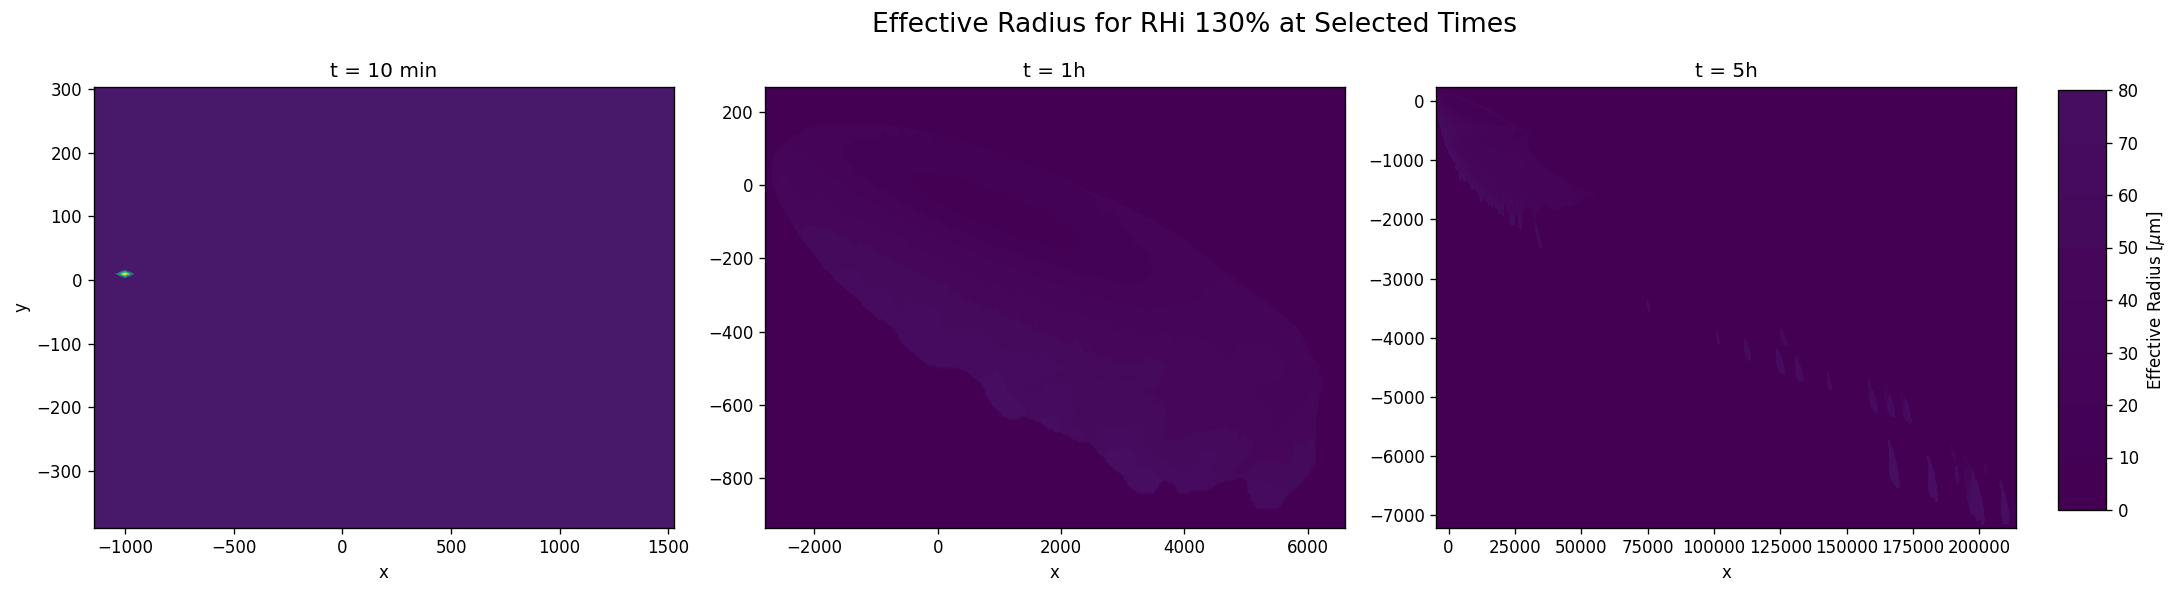

In [6]:
times = [1, 6, 30]
time_labels = {1: "t = 10 min", 6: "t = 1h", 30: "t = 5h"}

# Find global vmin and vmax for effective radius across all selected times
all_effrad = [epm_bypass_data['130T218L25'][t]["Effective radius"].values * 10**6 for t in times]
vmin = min([arr.min() for arr in all_effrad])
vmax = max([arr.max() for arr in all_effrad])

fig, axes = plt.subplots(1, len(times), figsize=(20, 5), dpi=120)
plt.subplots_adjust(right=0.85)  # Make space for colorbar

contourf_list = []
for ax, t in zip(axes, times):
    ds_t_time = epm_bypass_data['130T218L25'][t]
    X_map, Y_map = np.meshgrid(ds_t_time["x"], ds_t_time["y"])
    effrad = ds_t_time["Effective radius"] * 10**6
    cf = ax.contourf(X_map, Y_map, effrad, vmin=vmin, vmax=vmax)
    contourf_list.append(cf)
    ax.set_title(time_labels[t])
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")

# Add a single colorbar to the right of the figure
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.7])
fig.colorbar(contourf_list[-1], cax=cbar_ax, orientation='vertical', label=r'Effective Radius [$\mu$m]')

plt.suptitle(f"Effective Radius for RHi 130% at Selected Times", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Plot the ice particle number for each scenario
### t = 10 min, t = 1 hr, t = 5 hr, t = 12 hr, t = 20 hr, 
### or the last available timestep (in case of contrail death before 20hr)

#### RHi 130, T = 205 K

(100, 57)
(173, 189)
(1066, 4368)


/tmp/ipykernel_97904/3306837628.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


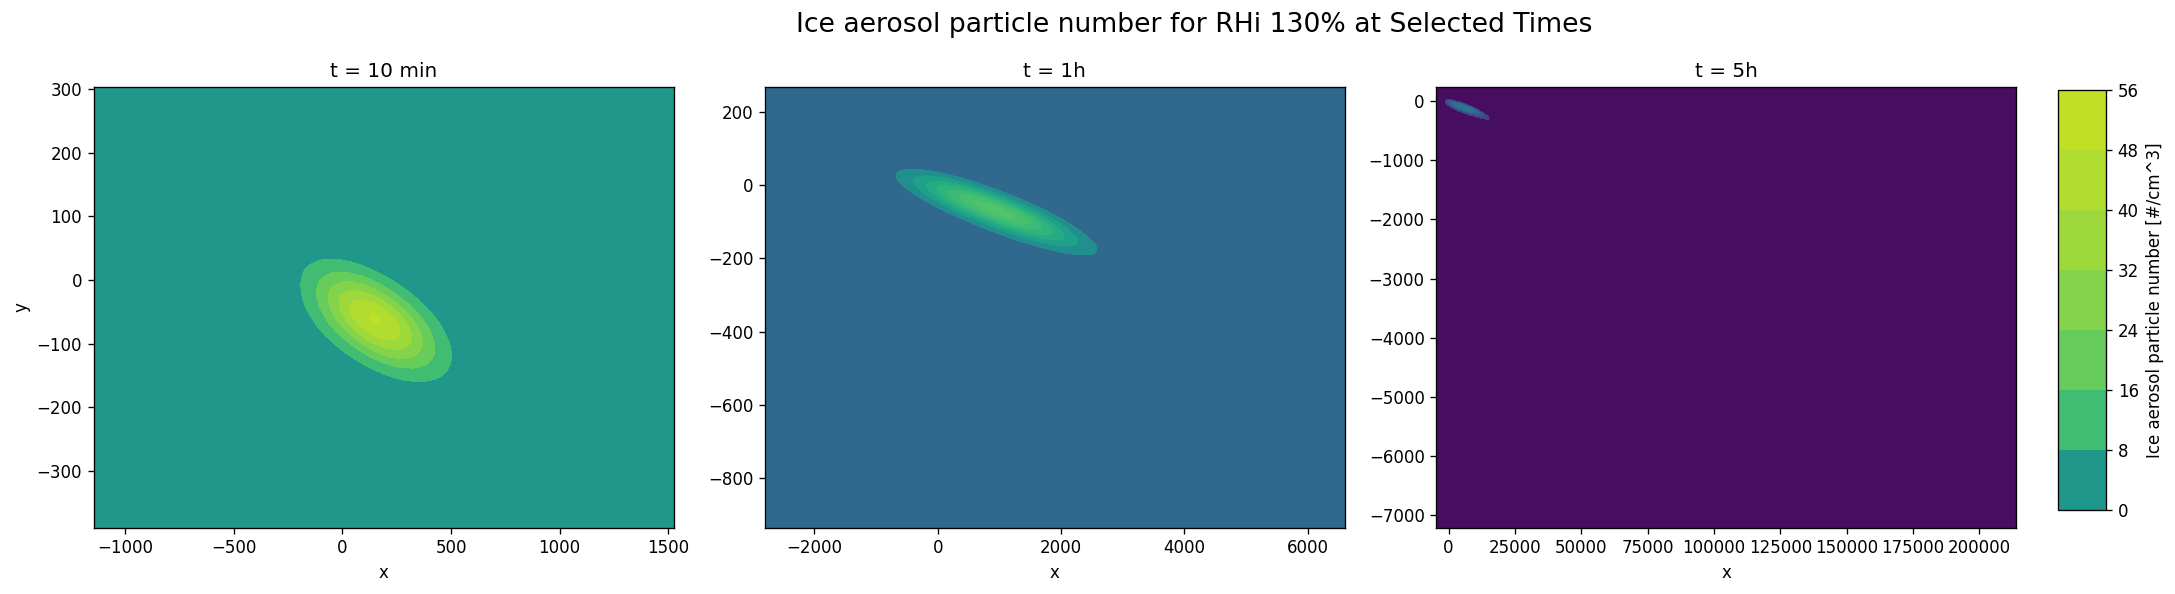

In [23]:
times = [1, 6, 30]
time_labels = {1: "t = 10 min", 6: "t = 1h", 30: "t = 5h"}

# Find global vmin and vmax for Ice aerosol particle number across all selected times
all_icenum = [epm_bypass_data['130T218L25'][t]["Ice aerosol particle number"].values for t in times]
vmin = min([arr.min() for arr in all_icenum])
vmax = max([arr.max() for arr in all_icenum])

fig, axes = plt.subplots(1, len(times), figsize=(20, 5), dpi=120)
plt.subplots_adjust(right=0.85)  # Make space for colorbar

contourf_list = []
for ax, t in zip(axes, times):
    ds_t_time = epm_bypass_data['130T218L25'][t]
    X_map, Y_map = np.meshgrid(ds_t_time["x"], ds_t_time["y"])
    icenum = ds_t_time["Ice aerosol particle number"]
    cf = ax.contourf(X_map, Y_map, icenum, vmin=1e-1, vmax=1e2, norm='log')
    print(icenum.shape)
    contourf_list.append(cf)
    ax.set_title(time_labels[t])
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")

# Add a single colorbar to the right of the figure
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.7])
fig.colorbar(contourf_list[0], cax=cbar_ax, orientation='vertical', label=r'Ice aerosol particle number [#/cm^3]')

plt.suptitle(f"Ice aerosol particle number for RHi 130% at Selected Times", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Minimum non-zero value for ice_particle_data: 1e-45


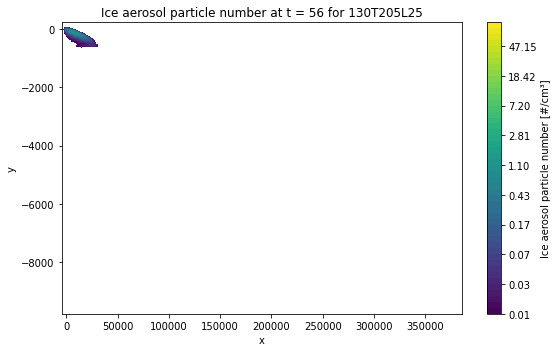

In [20]:
# Plot Ice aerosol particle number for t = 5h (i.e., t=30) with log color scale
ice_particle_data = epm_bypass_data['130T218L25'][-1]["Ice aerosol particle number"]

min_nonzero = ice_particle_data.values[ice_particle_data.values > 0].min()
print("Minimum non-zero value for ice_particle_data:", min_nonzero)

plt.figure(figsize=(8, 5))

ds_t_time = epm_bypass_data['130T218L25'][-1]
X_map, Y_map = np.meshgrid(ds_t_time["x"], ds_t_time["y"])

cf = plt.contourf(X_map, Y_map, ice_particle_data, levels=np.logspace(-2, 2, 50), norm='log')
plt.colorbar(cf, label='Ice aerosol particle number [#/cm³]')
plt.title(f'Ice aerosol particle number at {label} for 130T205L25')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()


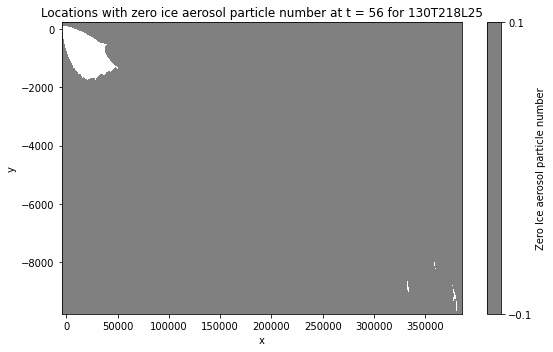

In [21]:
import numpy.ma as ma

# Mask everything except where rhi_data == 0
zero_mask = ma.masked_not_equal(ice_particle_data, 0)

plt.figure(figsize=(8, 5))
cf = plt.contourf(X_map, Y_map, zero_mask, levels=[-0.1, 0.1], colors='gray')
plt.colorbar(cf, label='Zero Ice aerosol particle number')
plt.title(f'Locations with zero ice aerosol particle number at {label} for 130T218L25')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()


Minimum non-zero value for ice_particle_data: 1e-45


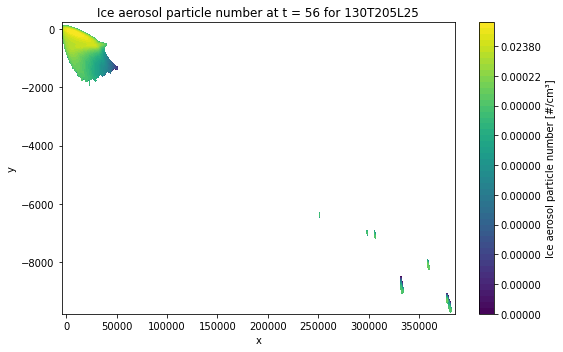

In [22]:
# Plot Ice aerosol particle number for t = 5h (i.e., t=30) with log color scale
ice_particle_data = epm_bypass_data['130T218L25'][-1]["Ice aerosol particle number"]

min_nonzero = ice_particle_data.values[ice_particle_data.values > 0].min()
print("Minimum non-zero value for ice_particle_data:", min_nonzero)

plt.figure(figsize=(8, 5))
cf = plt.contourf(X_map, Y_map, ice_particle_data, levels=np.logspace(-20, 0.01, 50), norm='log')
plt.colorbar(cf, label='Ice aerosol particle number [#/cm³]')
plt.title(f'Ice aerosol particle number at {label} for 130T205L25')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout()
plt.show()


In [11]:
print("Minimum value of ice aerosol particle number:", icenum.min().item())

Minimum value of ice aerosol particle number: 0.0


/tmp/ipykernel_97904/283853589.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


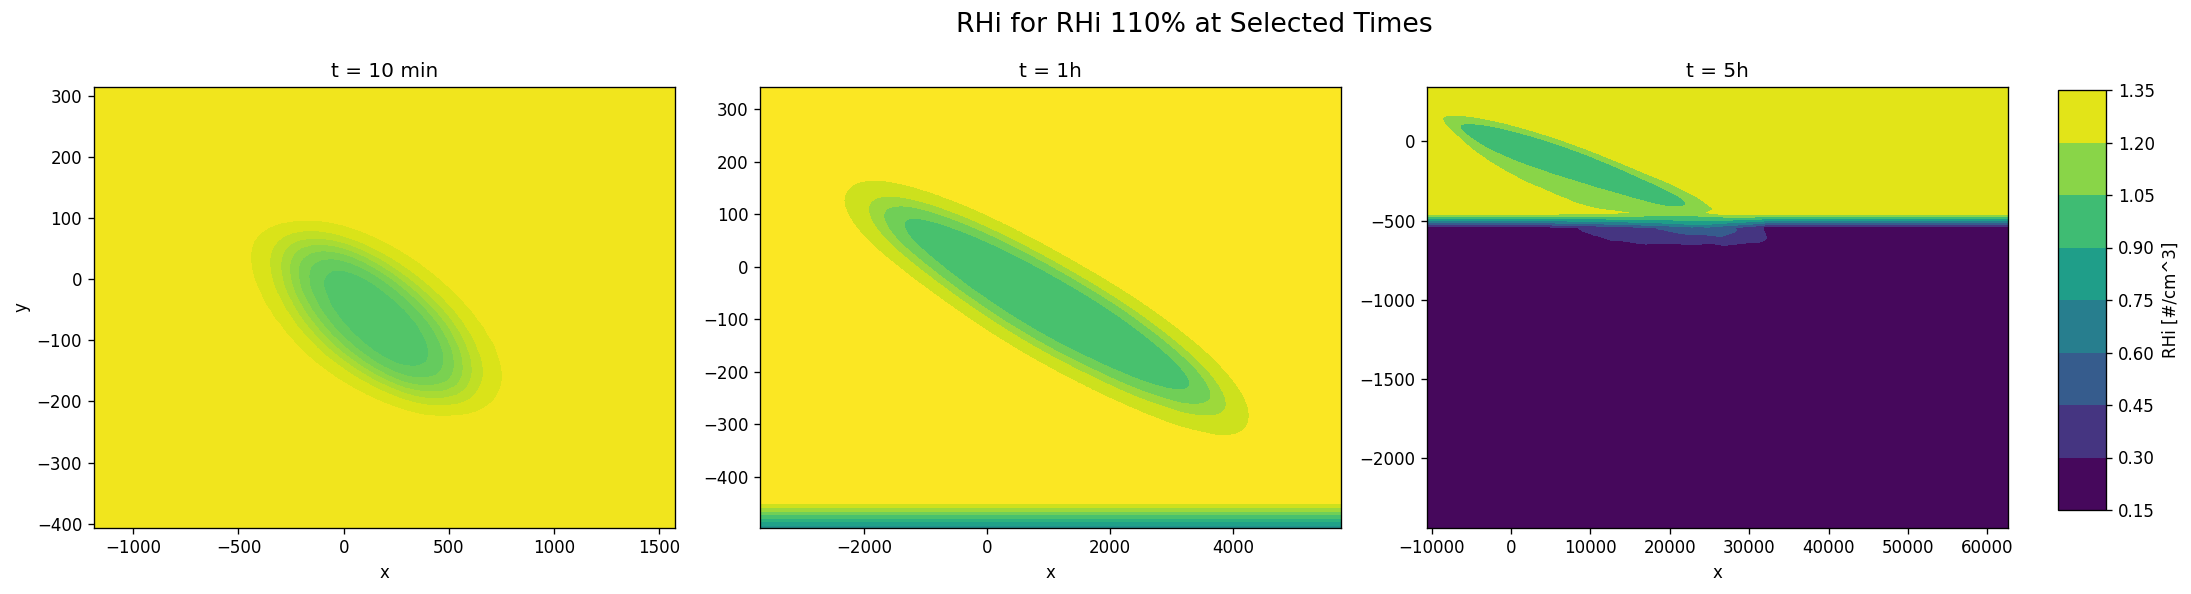

In [12]:
times = [1, 6, 30]
time_labels = {1: "t = 10 min", 6: "t = 1h", 30: "t = 5h"}

# Find global vmin and vmax for RHi across all selected times
all_icenum = [epm_bypass_data['130T205L25'][t]["RHi"].values for t in times]
vmin = min([arr.min() for arr in all_icenum])
vmax = max([arr.max() for arr in all_icenum])

fig, axes = plt.subplots(1, len(times), figsize=(20, 5), dpi=120)
plt.subplots_adjust(right=0.85)  # Make space for colorbar

contourf_list = []
for ax, t in zip(axes, times):
    ds_t_time = epm_bypass_data['130T205L25'][t]
    X_map, Y_map = np.meshgrid(ds_t_time["x"], ds_t_time["y"])
    icenum = ds_t_time["RHi"]
    cf = ax.contourf(X_map, Y_map, icenum, vmin=vmin, vmax=vmax)
    contourf_list.append(cf)
    ax.set_title(time_labels[t])
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")

# Add a single colorbar to the right of the figure
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.7])
fig.colorbar(contourf_list[-1], cax=cbar_ax, orientation='vertical', label=r'RHi [#/cm^3]')

plt.suptitle(f"RHi for RHi 110% at Selected Times", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

/tmp/ipykernel_97904/283853589.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


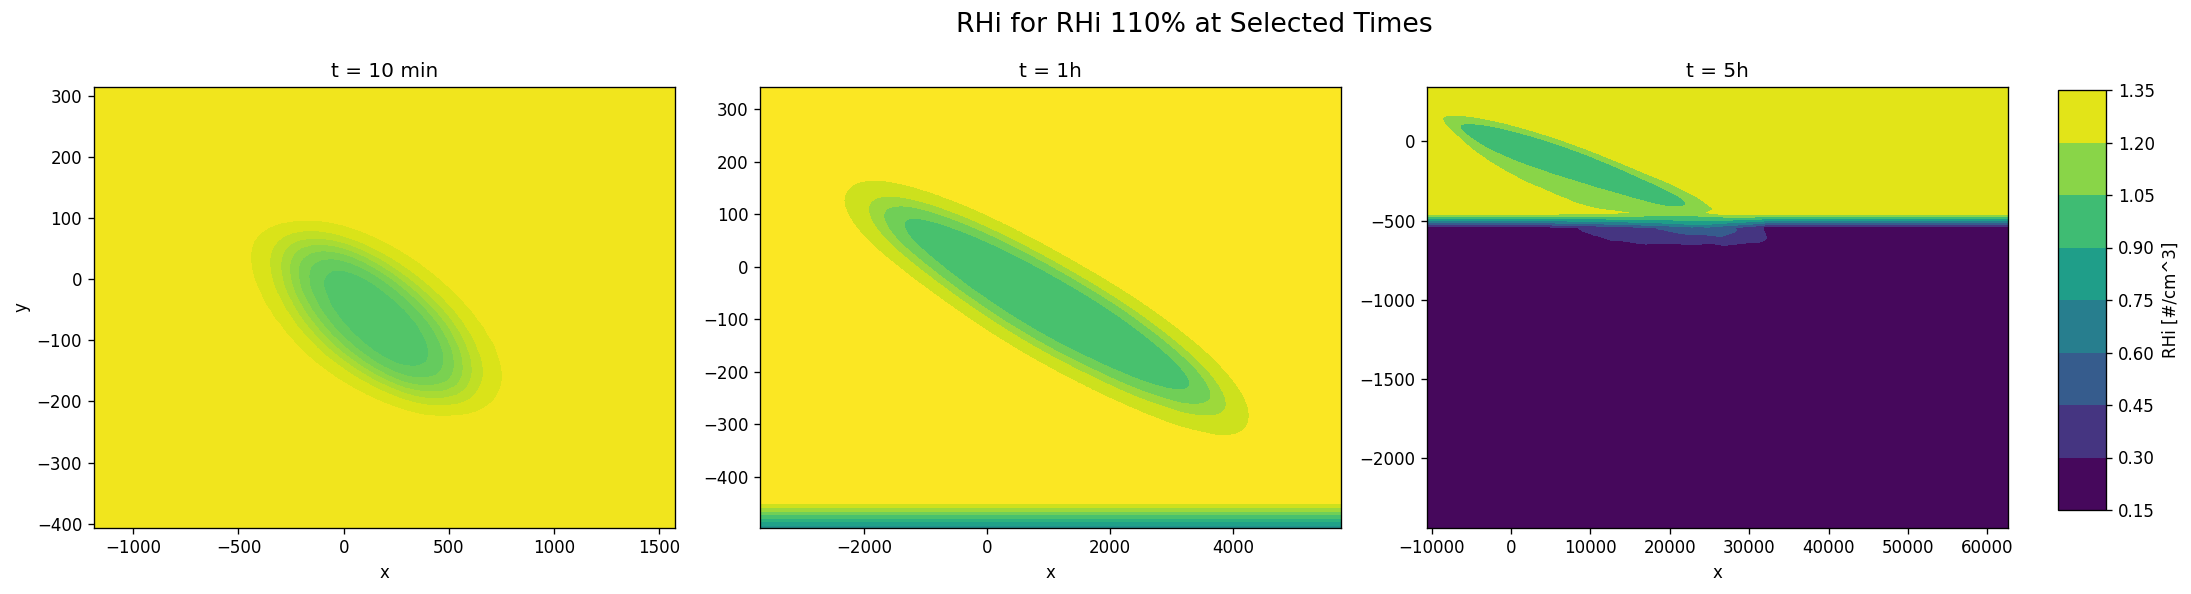

In [13]:
times = [1, 6, 30]
time_labels = {1: "t = 10 min", 6: "t = 1h", 30: "t = 5h"}

# Find global vmin and vmax for RHi across all selected times
all_icenum = [epm_bypass_data['130T205L25'][t]["RHi"].values for t in times]
vmin = min([arr.min() for arr in all_icenum])
vmax = max([arr.max() for arr in all_icenum])

fig, axes = plt.subplots(1, len(times), figsize=(20, 5), dpi=120)
plt.subplots_adjust(right=0.85)  # Make space for colorbar

contourf_list = []
for ax, t in zip(axes, times):
    ds_t_time = epm_bypass_data['130T205L25'][t]
    X_map, Y_map = np.meshgrid(ds_t_time["x"], ds_t_time["y"])
    icenum = ds_t_time["RHi"]
    cf = ax.contourf(X_map, Y_map, icenum, vmin=vmin, vmax=vmax)
    contourf_list.append(cf)
    ax.set_title(time_labels[t])
    ax.set_xlabel("x")
    if ax == axes[0]:
        ax.set_ylabel("y")

# Add a single colorbar to the right of the figure
cbar_ax = fig.add_axes([0.86, 0.15, 0.02, 0.7])
fig.colorbar(contourf_list[-1], cax=cbar_ax, orientation='vertical', label=r'RHi [#/cm^3]')

plt.suptitle(f"RHi for RHi 110% at Selected Times", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()